# 1 Basic Matrix/Vector Manipulation (20 points)

In [1]:
# (a) Define Matrix M and Vectors a,b,c in Python using Numpy.
import numpy as np

M = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [0, 2, 2]])
a = np.array([[1], [1], [0]])
b = np.array([[-1], [2], [5]])
c = np.array([[0], [2], [3], [2]])

In [2]:
# (b) Find the dot product of vectors a and b (i.e. a⊤b).
np.dot(np.transpose(a), b)

array([[1]])

In [3]:
# (c) Find the element-wise product of a and b [a1b1,a2b2,a3b3]T .
np.multiply(a, b)

array([[-1],
       [ 2],
       [ 0]])

In [4]:
# (d) Find (a⊤b)Ma.
# Answer: Can't be computed because the dimensions of a⊤b and M do not match.
# a⊤b is a 1x1 matrix, while M is a 4x3 matrix.
# Therefore, the multiplication (a⊤b)M is not defined.

In [5]:
# (e) Without using a loop, multiply each row of M element-wise by a.
# Briefly explain the logic of your code in your written report.
# Answer: We can use the numpy function np.multiply()
# to perform element-wise multiplication of M and a.
# Since a is a column vector with shape (3, 1), we can transpose it to make it
# a row vector with shape (1, 3) and
# then use broadcasting to multiply each row of M by the corresponding element of a.
# and then use broadcasting to multiply each row of M by the corresponding element of a.
# The code is as follows:
ME = np.multiply(M, a.T)
ME

array([[1, 2, 0],
       [4, 5, 0],
       [7, 8, 0],
       [0, 2, 0]])

In [6]:
np.sort(ME.flatten())

array([0, 0, 0, 0, 0, 1, 2, 2, 4, 5, 7, 8])

In [7]:
# (f) Without using a loop,
# sort all of the values of the new M from (e)
# in increasing order and plot them in your report.
# Briefly explain the logic of your code in your written report.
# Answer: We can use the numpy function np.sort() to sort
# all of the values of the new M from (e) in increasing order.
# The code is as follows:
sorted_ME = np.sort(ME.flatten())
sorted_ME

array([0, 0, 0, 0, 0, 1, 2, 2, 4, 5, 7, 8])

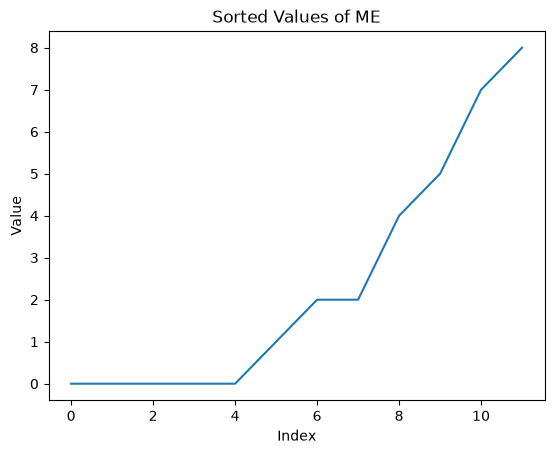

In [8]:
# Plot the sorted values
import matplotlib.pyplot as plt

plt.plot(sorted_ME)
plt.title("Sorted Values of ME")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

# 2. Basic Image Manipulations (40 points)

In [9]:
# (a) Read in the images, image1.jpg and image2.jpg,
# as color images using io.imread from the skimage package.
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import io

image1 = io.imread("ps0/image1.jpg")
image2 = io.imread("ps0/image2.jpg")
image1.shape, image2.shape, type(image1), type(image2)

((710, 950, 4), (710, 950, 4), numpy.ndarray, numpy.ndarray)

In [10]:
# (b) Convert the images to double precision and
# rescale them to stretch from minimum value 0 to maximum value 1.
image1 = image1.astype(np.float64)
image2 = image2.astype(np.float64)
img1_min, img1_max = image1.min(), image1.max()
img2_min, img2_max = image2.min(), image2.max()
image1 = (image1 - img1_min) / (img1_max - img1_min)
image2 = (image2 - img2_min) / (img2_max - img2_min)
image1.min(), image1.max(), image2.min(), image2.max()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

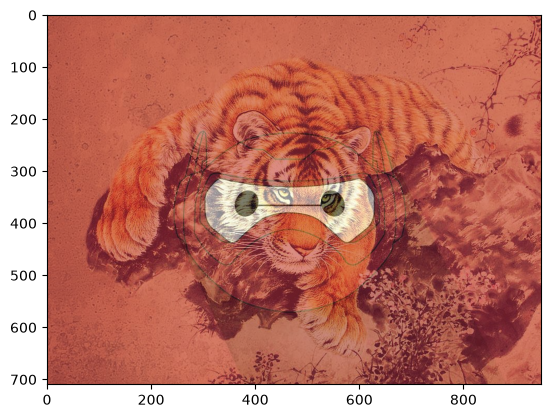

In [11]:
# (c) Add the images together and re-normalize them
# to have minimum value 0 and maximum value 1.
# Save and include this image in your report.
image_sum = image1 + image2
image_sum = image_sum.astype(np.float64)
img_sum_min, img_sum_max = image_sum.min(), image_sum.max()
image_sum = (image_sum - img_sum_min) / (img_sum_max - img_sum_min)
image_sum.min(), image_sum.max()
plt.imsave("ps0/image_sum.jpg", image_sum)
plt.imshow(image_sum)

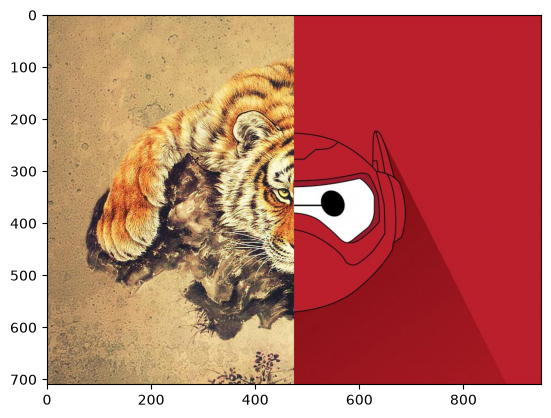

In [12]:
# (d) Create a new image such that the left half of the image
# is the left half of image1 and the right half of the image
# is the right half of image2.
# Save and include this image in your report.
img1_h, img1_w = image1.shape[:2]
img2_h, img2_w = image2.shape[:2]
img1_left = image1[:, : img1_w // 2, :]
img2_right = image2[:, img2_w // 2 :, :]
img_combined = np.concatenate((img1_left, img2_right), axis=1)
plt.imsave("ps0/image_combined.jpg", img_combined)
plt.imshow(img_combined)

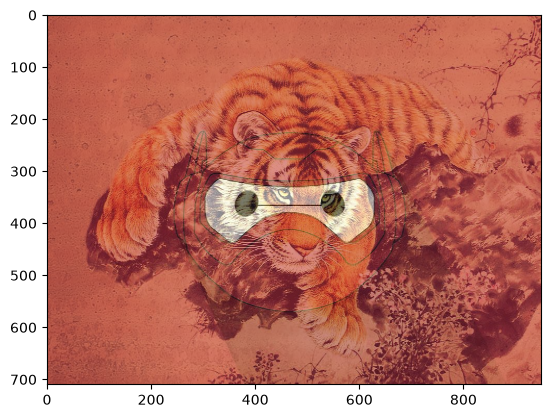

In [13]:
# (e) Using a for loop, create a new image such that every odd numbered
# row is the corresponding row from image1 and the every even row
# is the corresponding row from image2
# (Hint: Re member that indices start at 0 and not 1 in Python).
# Save and include this image in your report.
img_old_even = np.zeros_like(image1)
for i in range(img1_h):
    if i % 2 == 1:
        img_old_even[i] = image1[i]
    else:
        img_old_even[i] = image2[i]
plt.imsave("ps0/image_old_even.jpg", img_old_even)
plt.imshow(img_old_even)

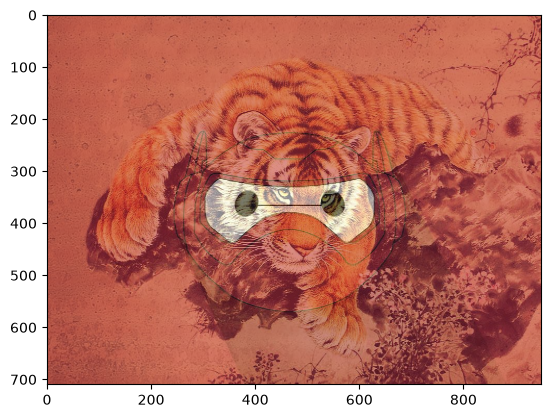

In [14]:
# (f) Accomplish the same task as part e without using a for-loop
# (the functions reshape and tile may be helpful here).
# Briefly explain the logic of your code in your written report.

mask_odd = np.array([[[0]], [[1]]])
mask_even = np.array([[[1]], [[0]]])
mask_odd_tiled = np.tile(
    mask_odd, (img1_h // 2, img1_w, 4)
)
mask_even_tiled = np.tile(
    mask_even, (img2_h // 2, img2_w, 4)
)
image1_odd = np.multiply(image1, mask_odd_tiled)
image2_even = np.multiply(image2, mask_even_tiled)
img_old_even_no_loop = image1_odd + image2_even
plt.imsave("ps0/img_old_even_no_loop.jpg", img_old_even_no_loop)
plt.imshow(img_old_even_no_loop)

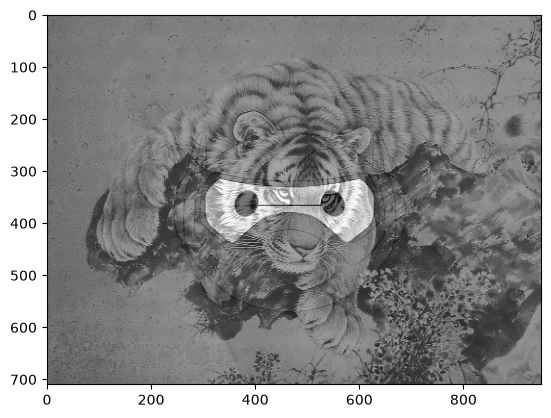

In [15]:
# (g) Convert the result from part f to a grayscale image. 
# Save and include the grayscale image in your report.

# Extract RGB channels (drop the Alpha channel at index 3)
img_old_even_no_loop_rgb = img_old_even_no_loop[:, :, :3]
# Standard luminance weights for Red, Green, and Blue
weights = np.array([0.2989, 0.5870, 0.1140])
img_old_even_no_loop_gray = np.dot(img_old_even_no_loop_rgb, weights)
plt.imshow(img_old_even_no_loop_gray, cmap='gray')
plt.imsave("ps0/img_old_even_no_loop_gray.jpg", img_old_even_no_loop_gray,  cmap='gray')

# 3. Singular Value Decomposition (40 points)

In [16]:
# What SVD Does to an Image?
# Array image => U, S, Vt
# U and V^T represent the patterns of rows and columns.
# Sigma S contains singular values arranged from largest to smallest.

# Why Do This?
# Data compression & Image reduction

import numpy as np

# 1. Read the image as grayscale
image1 = np.array([
    [10, 10, 10, 10, 10],
    [10, 80, 80, 80, 10],
    [10, 80, 99, 80, 10],
    [10, 80, 80, 80, 10],
    [10, 10, 10, 10, 10]
], dtype=float)

# 2. Calculate SVD
U, S, Vt = np.linalg.svd(image1, full_matrices=False)

# 3. Check the shapes of your outputs
print("Shape of U:  ", U.shape)
print("Shape of S:  ", S.shape)
print("Shape of Vt: ", Vt.shape)
print("S =", S.astype(np.int32))

# 4. Choose how many singular values to keep (e.g., top 3)
k = 3
# Reconstruct the image using matrix multiplication
# np.diag(S[:k]) turns the top k singular values into a 2D diagonal matrix
compressed_image = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]  # U @ Sigma @ VT.
compressed_image.astype(np.int64)

Shape of U:   (5, 5)
Shape of S:   (5,)
Shape of Vt:  (5, 5)
S = [249  17  12   0   0]


array([[10, 10,  9, 10, 10],
       [ 9, 79, 80, 80,  9],
       [10, 79, 99, 80, 10],
       [10, 79, 79, 79,  9],
       [10,  9,  9, 10, 10]])

In [17]:
np.diag(S[:k])

array([[249.28914702,   0.        ,   0.        ],
       [  0.        ,  17.55299813,   0.        ],
       [  0.        ,   0.        ,  12.15785485]])

In [18]:
U[:, :k] @ (np.diag(S[:k]) @ Vt[:k, :])

array([[10., 10., 10., 10., 10.],
       [10., 80., 80., 80., 10.],
       [10., 80., 99., 80., 10.],
       [10., 80., 80., 80., 10.],
       [10., 10., 10., 10., 10.]])

In [19]:
# (a) After reading in image1 as a grayscale image (this is done for you 
# in the code already) take the singular value decomposition of the image.
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import io

image1 = io.imread("ps0/image1.jpg", as_gray=True)
U, S, Vt = np.linalg.svd(image1, full_matrices=False)
print("Shape of U:  ", U.shape)
print("Shape of S:  ", S.shape)
print("Shape of Vt: ", Vt.shape)
print("S[:50] =", S.astype(np.int32)[:50])

Shape of U:   (710, 710)
Shape of S:   (710,)
Shape of Vt:  (710, 950)
S[:50] = [496  57  51  36  32  30  28  26  25  23  21  20  20  19  18  17  16  16
  15  15  15  14  14  13  13  12  12  12  12  12  12  11  11  11  10  10
  10  10  10  10  10   9   9   9   9   9   9   9   9   9]


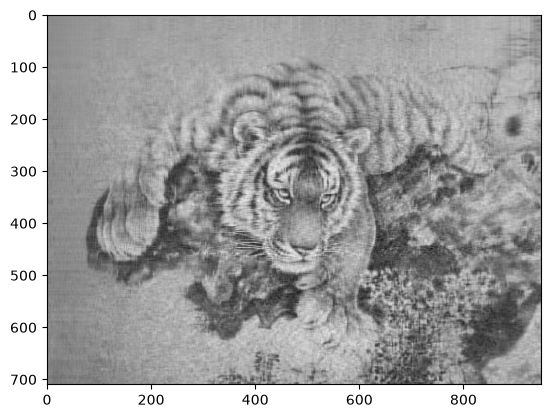

In [20]:
# (b) Recall from the discussion section that the best rank n approximation ...
# Save and include the best rank 1 approximation of the (grayscale) image1 in your report.
k = 50  # test k large
compressed_image = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]  # U @ Sigma @ VT.
plt.imsave("ps0/compressed_image_k50.jpg", compressed_image, cmap="gray")
plt.imshow(compressed_image, cmap="gray")

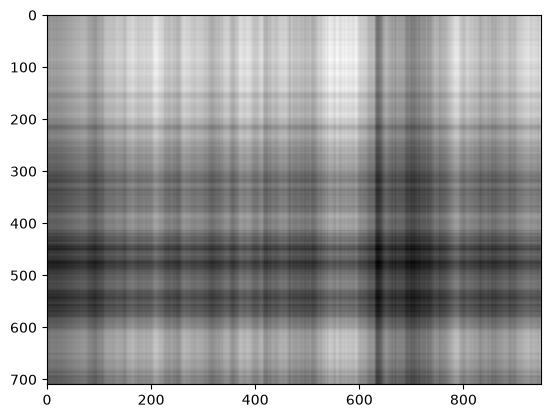

In [21]:
k = 1
compressed_image = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]  # U @ Sigma @ VT.
plt.imsave("ps0/compressed_image_k1.jpg", compressed_image, cmap="gray")
plt.imshow(compressed_image, cmap="gray")

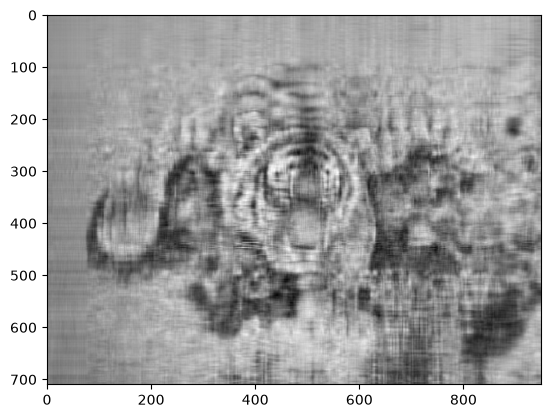

In [22]:
# (c) Save and include the best rank 20 approximation of the 
# (grayscale) image1 in your report.
k = 20
compressed_image = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]  # U @ Sigma @ VT.
plt.imsave("ps0/compressed_image_k20.jpg", compressed_image, cmap="gray")
plt.imshow(compressed_image, cmap="gray")